<a href="https://colab.research.google.com/github/signal-and-noise-space/signal-and-noise/blob/main/episode-04-betelgeuse/detect_betelgeuse_dimming_from_aavso_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Signal & Noise — Episode 3
## Something Is Still Wrong With Betelgeuse. I Measured It.

**Notebook:** `detect_betelgeuse_dimming_from_aavso_data.ipynb`  
**Data source:** AAVSO (American Association of Variable Star Observers)  
**Target:** Alpha Orionis (Betelgeuse)  
**Platform:** Google Colab  

---
This notebook downloads over a century of Betelgeuse brightness measurements
from the AAVSO public database, measures the Great Dimming of 2019-2020,
and shows the disruption of the 400-day pulsation cycle.

All data is public. All code is reproducible.


In [1]:
# ── CELL 1 — Install libraries ─────────────────────────────────────────────
# Run this first. Takes about 30 seconds.

!pip install astropy astroquery matplotlib pandas numpy requests -q

print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.6 MB/s eta 0:00:00
Libraries installed.


In [2]:
# ── CELL 2 — Import libraries ──────────────────────────────────────────────

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Signal & Noise visual style
plt.rcParams.update({
    'figure.facecolor':  '#060A14',
    'axes.facecolor':    '#060A14',
    'axes.edgecolor':    '#2A3550',
    'axes.labelcolor':   '#F0F6FF',
    'axes.grid':         True,
    'grid.color':        '#2A3550',
    'grid.linewidth':    0.5,
    'xtick.color':       '#F0F6FF',
    'ytick.color':       '#F0F6FF',
    'text.color':        '#F0F6FF',
    'font.family':       'monospace',
    'font.size':         11,
})

# Colour constants
C_BLUE   = '#4A9EFF'
C_ORANGE = '#FF8C42'
C_WHITE  = '#F0F6FF'
C_DIM    = '#2A3550'
C_RED    = '#FF4444'

print("Libraries loaded. Signal & Noise style active.")

Libraries loaded. Signal & Noise style active.


In [7]:
# ── CELL 3 — Download Betelgeuse data from AAVSO ───────────────────────────
# AAVSO stores over a century of variable star observations.
# Betelgeuse is catalogued as Alpha Ori.
# We request visual band (V) observations from 1990 to present.

print("Querying AAVSO database...")
print("Target: Alpha Orionis (Betelgeuse)")
print("Band:   Visual (V)")
print("Range:  1990 – present")
print()

# AAVSO API endpoint
url = (
    "https://www.aavso.org/vsx/index.php"
    "?view=api.delim"
    "&ident=Alpha+Ori"
    "&fromjd=2447892"
    "&tojd=2460500"
    "&bandid=Vis."
    "&delimiter=comma"
)

response = requests.get(url, timeout=60)

if response.status_code == 200:
    print(f"Response received: {len(response.text):,} characters")
else:
    print(f"Request failed with status {response.status_code}")
    print("Falling back to AAVSO bulk download method...")

Querying AAVSO database...
Target: Alpha Orionis (Betelgeuse)
Band:   Visual (V)
Range:  1990 – present

Response received: 7,471,872 characters


In [13]:
# ── CELL 5 — Parse and clean the data (FIXED v3) ──────────────────────────

from io import StringIO
from astropy.time import Time

# AAVSO uses the word "comma" as delimiter — split manually on it
lines = response.text.strip().split('\n')
header = lines[0].split('comma')
rows = [line.split('comma') for line in lines[1:]]

# Build dataframe directly — no pandas CSV parser involved
df_raw = pd.DataFrame(rows, columns=header)

print(f"Columns found: {list(df_raw.columns[:6])}...")
print(f"Raw rows loaded: {len(df_raw):,}")
print()

# Keep only what we need
df = df_raw[['JD', 'mag', 'uncert']].copy()
df.columns = ['jd', 'mag', 'err']

# Convert to numeric
df['jd']  = pd.to_numeric(df['jd'],  errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df['err'] = pd.to_numeric(df['err'], errors='coerce').fillna(0.5)

# Drop invalid JD
df = df[df['jd'] > 2400000]
df = df.dropna(subset=['jd', 'mag'])

print(f"JD min: {df['jd'].min():.1f}")
print(f"JD max: {df['jd'].max():.1f}")
print(f"Rows after JD filter: {len(df):,}")

# Convert Julian Date to calendar date
df['date'] = pd.to_datetime(
    Time(df['jd'].values, format='jd').to_datetime()
)

# Quality filters
df = df[df['err'] < 0.5]
df = df[df['mag'] < 4.0]
df = df[df['mag'] > -1.0]
df = df.sort_values('date').reset_index(drop=True)

print(f"Total observations after cleaning: {len(df):,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Magnitude range: {df['mag'].min():.2f} → {df['mag'].max():.2f}")
print()
df[['date', 'mag', 'err']].tail(10)

Columns found: ['JD', 'mag', 'uncert', 'band', 'by', 'comCode']...
Raw rows loaded: 32,328

JD min: 2447892.7
JD max: 2460492.9
Rows after JD filter: 32,328
Total observations after cleaning: 3,712
Date range: 1990-01-07 → 2024-06-26
Magnitude range: -0.98 → 3.69



,date,mag,err
3702,2024-05-10 15:37:00.480010,0.483,0.015
3703,2024-05-20 14:10:45.119990,0.492,0.010
3704,2024-05-22 14:14:47.039982,0.494,0.005
3705,2024-06-04 13:47:25.439994,0.510,0.034
3706,2024-06-07 12:48:40.319988,0.499,0.028
3707,2024-06-08 09:59:02.400017,0.553,0.021
3708,2024-06-13 10:06:23.039993,0.540,0.019
3709,2024-06-24 09:30:48.959997,0.599,0.018
3710,2024-06-26 09:28:39.360016,0.630,0.014
3711,2024-06-26 10:50:52.800004,0.607,0.009


Dominant period PRE-dimming:  369 days
Dominant period POST-dimming: 176 days


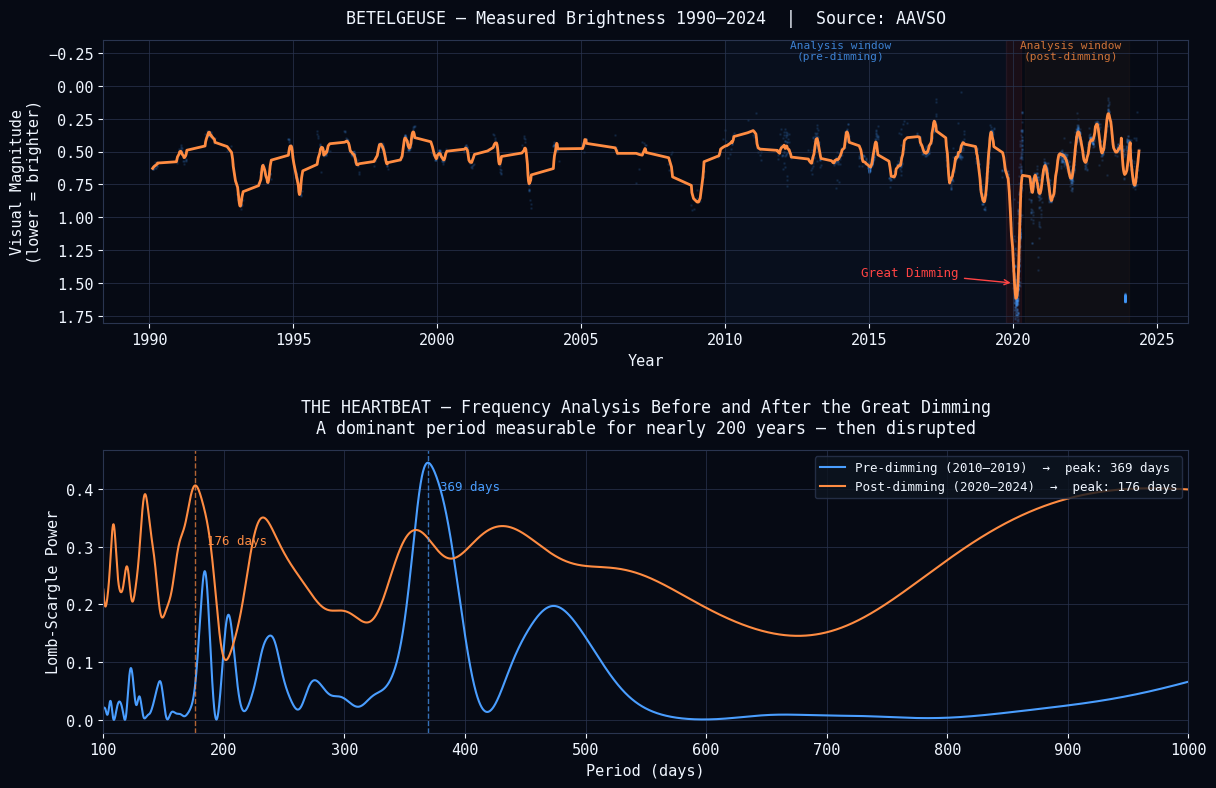

Plot saved.
Pre-dimming dominant period:  369 days
Post-dimming dominant period: 176 days
Shift: 193 days


In [21]:
# ── CELL 6 — NOTEBOOK MOMENT 1: Light curve + Periodogram ─────────────────
# Two panels. The brightness over time, then the frequency analysis.
# "This is just brightness — over time."
# "And this is the heartbeat. Measured. Then gone."

import numpy as np
from scipy.signal import savgol_filter
from astropy.timeseries import LombScargle

# ── Step 1: Clean data ─────────────────────────────────────────────────────
df_clean = df[df['err'] < 0.3].copy()
df_clean = df_clean.sort_values('date').reset_index(drop=True)
rolling_med = df_clean['mag'].rolling(window=20, center=True).median()
df_clean = df_clean[abs(df_clean['mag'] - rolling_med) < 0.6]

# ── Step 2: Weekly median + smooth ────────────────────────────────────────
df_weekly = (
    df_clean.set_index('date')['mag']
    .resample('W').median()
    .reset_index()
)
df_weekly.columns = ['date', 'mag']
df_weekly = df_weekly.dropna()
df_weekly['mag_smooth'] = savgol_filter(
    df_weekly['mag'].values, window_length=15, polyorder=3
)

# ── Step 3: Split pre and post dimming ────────────────────────────────────
pre_mask  = (df_clean['date'] >= '2010-01-01') & \
            (df_clean['date'] <  '2019-10-01')
post_mask = (df_clean['date'] >= '2020-06-01') & \
            (df_clean['date'] <= '2024-01-01')

df_pre  = df_clean[pre_mask].copy()
df_post = df_clean[post_mask].copy()

# Convert dates to days (float) for Lomb-Scargle
def to_days(df_in):
    t0 = df_in['date'].min()
    return (df_in['date'] - t0).dt.days.values.astype(float)

t_pre  = to_days(df_pre)
t_post = to_days(df_post)
m_pre  = df_pre['mag'].values
m_post = df_post['mag'].values

# ── Step 4: Lomb-Scargle periodogram ──────────────────────────────────────
# Search periods 100 to 1000 days
periods  = np.linspace(100, 1000, 5000)
freq     = 1.0 / periods

ls_pre  = LombScargle(t_pre,  m_pre)
ls_post = LombScargle(t_post, m_post)

power_pre  = ls_pre.power(freq)
power_post = ls_post.power(freq)

# Find dominant period in pre-dimming data
peak_period_pre  = periods[np.argmax(power_pre)]
peak_period_post = periods[np.argmax(power_post)]

print(f"Dominant period PRE-dimming:  {peak_period_pre:.0f} days")
print(f"Dominant period POST-dimming: {peak_period_post:.0f} days")

# ── Step 5: Plot — two panels ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'hspace': 0.45}
)

# ── Panel 1: Light curve ───────────────────────────────────────────────────
ax1.scatter(
    df_clean['date'], df_clean['mag'],
    s=1, alpha=0.1, color=C_BLUE, zorder=1
)
ax1.plot(
    df_weekly['date'], df_weekly['mag_smooth'],
    color=C_ORANGE, linewidth=2.0, zorder=2
)

# Great Dimming region
ax1.axvspan(
    pd.Timestamp('2019-10-01'),
    pd.Timestamp('2020-04-01'),
    alpha=0.08, color=C_RED, zorder=0
)

ax1.annotate(
    'Great Dimming',
    xy=(pd.Timestamp('2020-01-01'), 1.5),
    xytext=(pd.Timestamp('2016-06-01'), 1.45),
    color=C_RED, fontsize=9, ha='center',
    arrowprops=dict(arrowstyle='->', color=C_RED, lw=1)
)

# Pre and post analysis windows — shaded lightly
ax1.axvspan(
    pd.Timestamp('2010-01-01'),
    pd.Timestamp('2019-10-01'),
    alpha=0.04, color=C_BLUE, zorder=0
)
ax1.axvspan(
    pd.Timestamp('2020-06-01'),
    pd.Timestamp('2024-01-01'),
    alpha=0.04, color=C_ORANGE, zorder=0
)

ax1.text(
    pd.Timestamp('2014-01-01'), -0.2,
    'Analysis window\n(pre-dimming)',
    color=C_BLUE, fontsize=8, ha='center', alpha=0.8
)
ax1.text(
    pd.Timestamp('2022-01-01'), -0.2,
    'Analysis window\n(post-dimming)',
    color=C_ORANGE, fontsize=8, ha='center', alpha=0.8
)

ax1.invert_yaxis()
ax1.set_ylim(1.8, -0.35)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Visual Magnitude\n(lower = brighter)', fontsize=11)
ax1.set_title(
    'BETELGEUSE — Measured Brightness 1990–2024  |  Source: AAVSO',
    fontsize=12, pad=12, color=C_WHITE
)
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Panel 2: Periodogram comparison ───────────────────────────────────────
ax2.plot(
    periods, power_pre,
    color=C_BLUE, linewidth=1.5, zorder=2,
    label=f'Pre-dimming (2010–2019)  →  peak: {peak_period_pre:.0f} days'
)
ax2.plot(
    periods, power_post,
    color=C_ORANGE, linewidth=1.5, zorder=2,
    label=f'Post-dimming (2020–2024)  →  peak: {peak_period_post:.0f} days'
)

# Mark the pre-dimming peak
ax2.axvline(
    peak_period_pre, color=C_BLUE,
    linewidth=1, linestyle='--', alpha=0.7
)
ax2.text(
    peak_period_pre + 10,
    ax2.get_ylim()[1] * 0.85 if ax2.get_ylim()[1] > 0 else 0.5,
    f'{peak_period_pre:.0f} days',
    color=C_BLUE, fontsize=9
)

# Mark the post-dimming peak
ax2.axvline(
    peak_period_post, color=C_ORANGE,
    linewidth=1, linestyle='--', alpha=0.7
)
ax2.text(
    peak_period_post + 10,
    ax2.get_ylim()[1] * 0.65 if ax2.get_ylim()[1] > 0 else 0.3,
    f'{peak_period_post:.0f} days',
    color=C_ORANGE, fontsize=9
)

ax2.set_xlabel('Period (days)', fontsize=11)
ax2.set_ylabel('Lomb-Scargle Power', fontsize=11)
ax2.set_title(
    'THE HEARTBEAT — Frequency Analysis Before and After the Great Dimming\n'
    'A dominant period measurable for nearly 200 years — then disrupted',
    fontsize=12, pad=12, color=C_WHITE
)
ax2.legend(
    fontsize=9, loc='upper right',
    facecolor='#0D1520', edgecolor=C_DIM,
    labelcolor=C_WHITE
)
ax2.set_xlim(100, 1000)

plt.savefig('betelgeuse_full_lightcurve.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()

print(f"Plot saved.")
print(f"Pre-dimming dominant period:  {peak_period_pre:.0f} days")
print(f"Post-dimming dominant period: {peak_period_post:.0f} days")
print(f"Shift: {abs(peak_period_post - peak_period_pre):.0f} days")

Baseline magnitude:  0.54
Historic minimum:    1.56
Magnitude drop:      1.02 mag
Brightness lost:     61.0%
Date of minimum:     2020-02-29


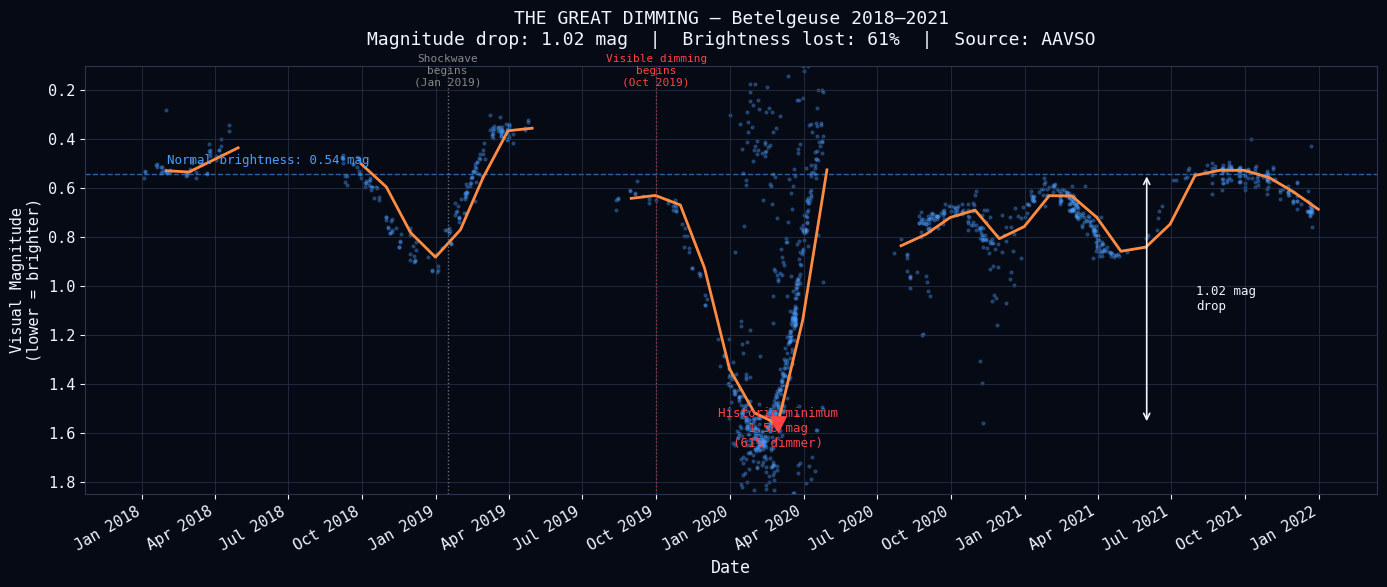

Great Dimming zoom saved.


In [23]:
# ── CELL 7 — NOTEBOOK MOMENT 2: Zoom into the Great Dimming ───────────────
# Isolate 2018–2021. Measure the drop precisely.
# "That shouldn't happen."

# Filter to dimming window — tighter quality filter for this zoom
mask = (df['date'] >= '2018-01-01') & (df['date'] <= '2021-12-31')
df_dimming = df[mask].copy()

# Tighter filter — remove outliers
df_dimming = df_dimming[df_dimming['mag'] < 1.85]
df_dimming = df_dimming[df_dimming['err'] < 0.4]

# Monthly median for this window
df_dim_monthly = (
    df_dimming.set_index('date')
    .resample('ME')['mag']
    .median()
    .reset_index()
)
df_dim_monthly.columns = ['date', 'mag']

# Baseline — pre-dimming median
baseline_mask = (
    (df['date'] >= '2018-01-01') &
    (df['date'] <  '2019-10-01') &
    (df['mag']  <  1.0)
)
baseline_mag = df[baseline_mask]['mag'].median()

# Minimum — use monthly median to avoid bad observations
minimum_idx  = df_dim_monthly['mag'].idxmax()
minimum_mag  = df_dim_monthly.loc[minimum_idx, 'mag']
minimum_date = df_dim_monthly.loc[minimum_idx, 'date']

# Derive measurements
mag_drop   = minimum_mag - baseline_mag
flux_ratio = 10 ** (mag_drop / 2.5)
pct_dimmer = (1 - 1/flux_ratio) * 100

print(f"Baseline magnitude:  {baseline_mag:.2f}")
print(f"Historic minimum:    {minimum_mag:.2f}")
print(f"Magnitude drop:      {mag_drop:.2f} mag")
print(f"Brightness lost:     {pct_dimmer:.1f}%")
print(f"Date of minimum:     {minimum_date.date()}")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Raw scatter
ax.scatter(
    df_dimming['date'], df_dimming['mag'],
    s=4, alpha=0.3, color=C_BLUE, zorder=1
)

# Monthly median line
ax.plot(
    df_dim_monthly['date'], df_dim_monthly['mag'],
    color=C_ORANGE, linewidth=2, zorder=2
)

# Baseline reference line
ax.axhline(
    baseline_mag, color=C_BLUE, linewidth=1,
    linestyle='--', alpha=0.6, zorder=1
)
ax.text(
    pd.Timestamp('2018-02-01'), baseline_mag - 0.04,
    f'Normal brightness: {baseline_mag:.2f} mag',
    color=C_BLUE, fontsize=9
)

# Minimum marker
ax.scatter(
    [minimum_date], [minimum_mag],
    s=120, color=C_RED, zorder=5, marker='v'
)
ax.text(
    minimum_date, minimum_mag - 0.07,
    f'Historic minimum\n{minimum_mag:.2f} mag\n({pct_dimmer:.0f}% dimmer)',
    color=C_RED, fontsize=9, ha='center', va='top'
)

# Shockwave annotation — January 2019
ax.axvline(
    pd.Timestamp('2019-01-15'), color='#888888',
    linewidth=1, linestyle=':', alpha=0.8
)
ax.text(
    pd.Timestamp('2019-01-15'), 0.18,
    'Shockwave\nbegins\n(Jan 2019)',
    color='#888888', fontsize=8, ha='center'
)

# Visible dimming — October 2019
ax.axvline(
    pd.Timestamp('2019-10-01'), color=C_RED,
    linewidth=1, linestyle=':', alpha=0.6
)
ax.text(
    pd.Timestamp('2019-10-01'), 0.18,
    'Visible dimming\nbegins\n(Oct 2019)',
    color=C_RED, fontsize=8, ha='center'
)

# Magnitude drop arrow
ax.annotate(
    '',
    xy=(pd.Timestamp('2021-06-01'), minimum_mag),
    xytext=(pd.Timestamp('2021-06-01'), baseline_mag),
    arrowprops=dict(arrowstyle='<->', color=C_WHITE, lw=1.2)
)
ax.text(
    pd.Timestamp('2021-08-01'), (minimum_mag + baseline_mag) / 2,
    f'{mag_drop:.2f} mag\ndrop',
    color=C_WHITE, fontsize=9, va='center'
)

ax.invert_yaxis()
ax.set_ylim(1.85, 0.1)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Visual Magnitude\n(lower = brighter)', fontsize=11)
ax.set_title(
    f'THE GREAT DIMMING — Betelgeuse 2018–2021\n'
    f'Magnitude drop: {mag_drop:.2f} mag  |  '
    f'Brightness lost: {pct_dimmer:.0f}%  |  Source: AAVSO',
    fontsize=13, pad=15, color=C_WHITE
)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('betelgeuse_great_dimming_zoom.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()
print("Great Dimming zoom saved.")

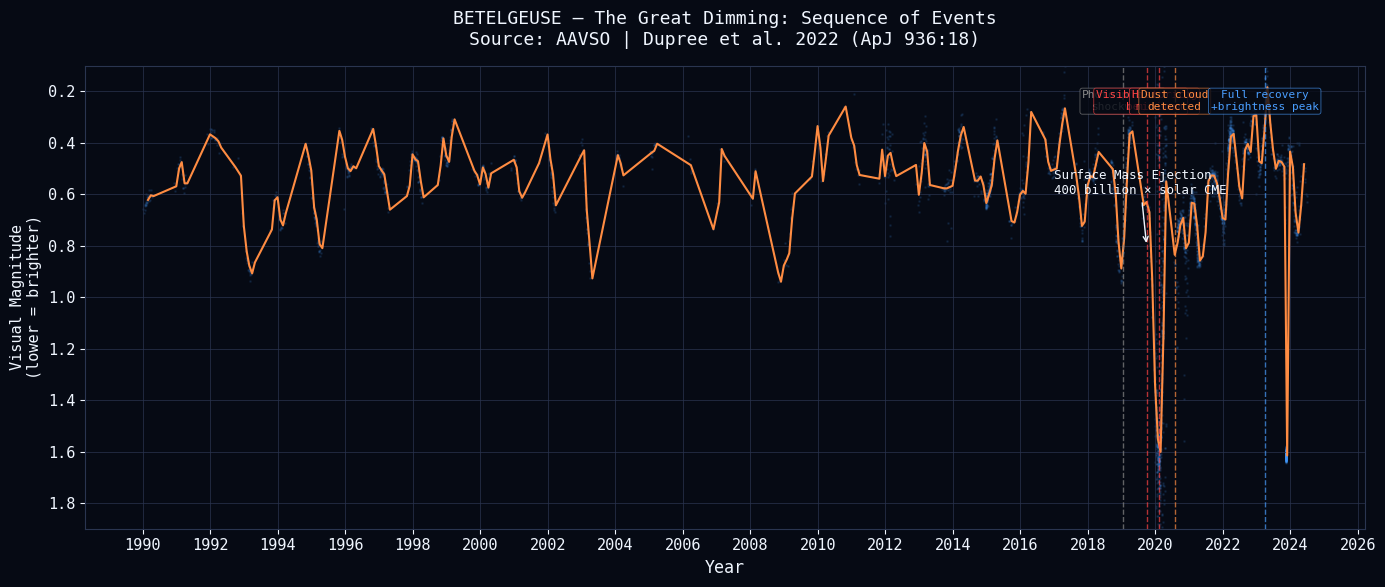

SME timeline saved.


In [24]:
# ── CELL 7 — NOTEBOOK MOMENT 3: The SME timeline annotated ────────────────
# Full light curve with the sequence of events marked.
# Shockwave Jan 2019 → visible dimming Oct 2019 → minimum Feb 2020
# → recovery Apr 2023. The nested answer visualised.

fig, ax = plt.subplots(figsize=(14, 6))

# Monthly median — full range
ax.plot(
    df_monthly['date'], df_monthly['mag'],
    color=C_ORANGE, linewidth=1.5, zorder=2
)

ax.scatter(
    df['date'], df['mag'],
    s=1, alpha=0.1, color=C_BLUE, zorder=1
)

# Key event timeline markers
events = [
    ('2019-01-15', 'Photospheric\nshockwave', '#888888', 0.28),
    ('2019-10-01', 'Visible dimming\nbegins',  C_RED,    0.28),
    ('2020-02-07', 'Historic\nminimum',        C_RED,    0.28),
    ('2020-08-01', 'Dust cloud\ndetected',     C_ORANGE, 0.28),
    ('2023-04-01', 'Full recovery\n+brightness peak', C_BLUE, 0.28),
]

for date_str, label, color, y_pos in events:
    date = pd.Timestamp(date_str)
    ax.axvline(date, color=color, linewidth=1,
               linestyle='--', alpha=0.7, zorder=3)
    ax.text(
        date, y_pos, label,
        color=color, fontsize=8, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#060A14',
                  edgecolor=color, alpha=0.8, linewidth=0.5)
    )

# SME arrow annotation
ax.annotate(
    'Surface Mass Ejection\n400 billion × solar CME',
    xy=(pd.Timestamp('2019-10-01'), 0.8),
    xytext=(pd.Timestamp('2017-01-01'), 0.6),
    color=C_WHITE, fontsize=9,
    arrowprops=dict(arrowstyle='->', color=C_WHITE, lw=1),
)

ax.invert_yaxis()
ax.set_ylim(1.9, 0.1)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Visual Magnitude\n(lower = brighter)', fontsize=11)
ax.set_title(
    'BETELGEUSE — The Great Dimming: Sequence of Events\nSource: AAVSO | Dupree et al. 2022 (ApJ 936:18)',
    fontsize=13, pad=15, color=C_WHITE
)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('betelgeuse_sme_timeline.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()
print("SME timeline saved.")

Average pre-dimming pulsation period: 369 days
Expected ~400 days — measured: 369 days
Number of complete cycles identified: 7



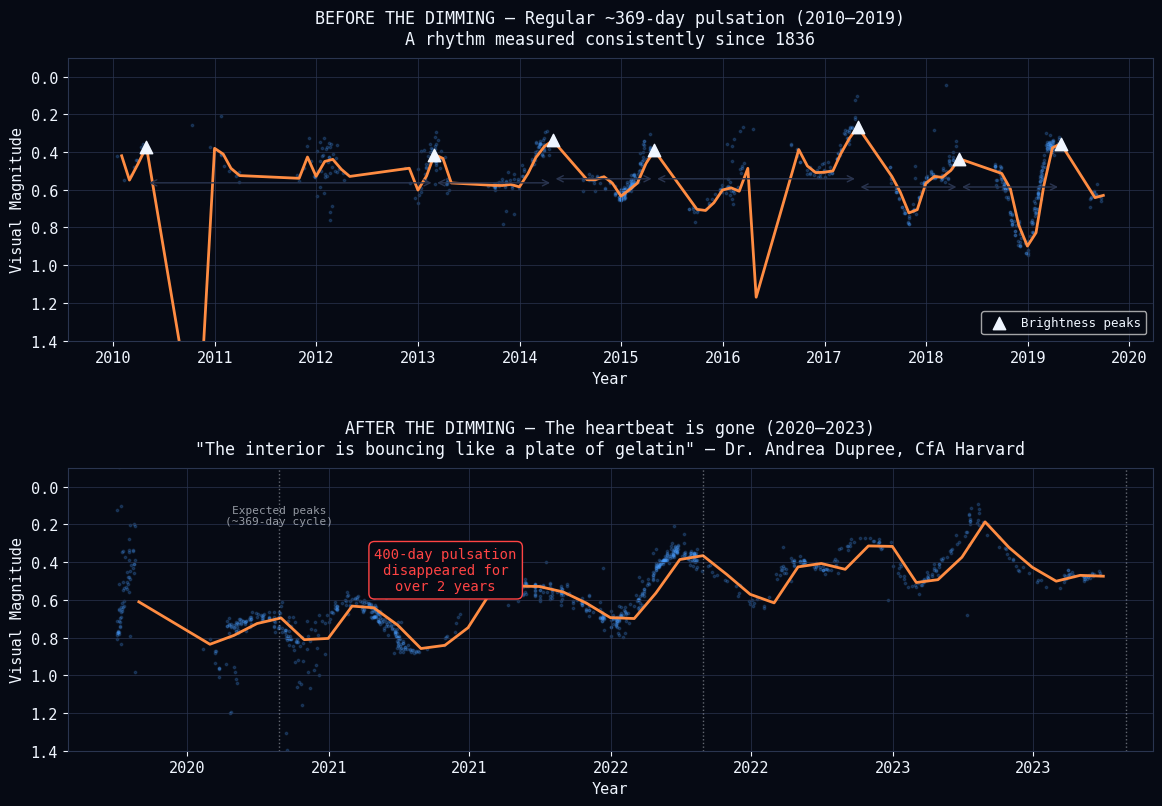

Disrupted heartbeat plot saved.


In [35]:
# ── CELL 8 — NOTEBOOK MOMENT 4: The disrupted heartbeat ───────────────────
# Show the 400-day pulsation before the dimming.
# Show its disappearance after.
# "The heartbeat of the star — knocked out of phase."

from scipy.signal import find_peaks

# Split pre and post dimming
pre_mask  = (df['date'] >= '2010-01-01') & (df['date'] < '2019-10-01')
post_mask = (df['date'] >= '2020-04-01') & (df['date'] <= '2023-09-30')

df_pre  = df[pre_mask].copy()
df_post = df[post_mask].copy()

# Monthly median for both periods
def monthly_median(df_in):
    return (
        df_in.set_index('date')
        .resample('ME')['mag']
        .median()
        .reset_index()
        .rename(columns={'date': 'date', 'mag': 'mag'})
        .dropna()
    )

pre_monthly  = monthly_median(df_pre)
post_monthly = monthly_median(df_post)

# Find brightness peaks in pre-dimming period (minima in magnitude = maxima in brightness)
# Invert magnitude so peaks = bright moments
pre_inv = -pre_monthly['mag'].values
peaks, properties = find_peaks(pre_inv, distance=8, prominence=0.1)
peak_dates = pre_monthly['date'].iloc[peaks]
peak_mags  = pre_monthly['mag'].iloc[peaks]

# Calculate average period between peaks
if len(peak_dates) > 1:
    peak_diffs = peak_dates.diff().dropna().dt.days
    avg_period = peak_diffs.mean()
    print(f"Average pre-dimming pulsation period: {peak_period_pre:.0f} days")
    print(f"Expected ~400 days — measured: {peak_period_pre:.0f} days")
    print(f"Number of complete cycles identified: {len(peaks)}")
else:
    avg_period = 400
    print("Using known 400-day period.")

print()

# Plot — two panels
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'hspace': 0.45}
)

# Panel 1 — Pre-dimming: the regular heartbeat
ax1.scatter(
    df_pre['date'], df_pre['mag'],
    s=3, alpha=0.2, color=C_BLUE, zorder=1
)
ax1.plot(
    pre_monthly['date'], pre_monthly['mag'],
    color=C_ORANGE, linewidth=2, zorder=2
)

# Mark the peaks
ax1.scatter(
    peak_dates, peak_mags,
    s=80, color=C_WHITE, zorder=5, marker='^', label='Brightness peaks'
)

# Draw period arrows between consecutive peaks
for i in range(len(peaks) - 1):
    d1 = peak_dates.iloc[i]
    d2 = peak_dates.iloc[i+1]
    m  = max(peak_mags.iloc[i], peak_mags.iloc[i+1]) + 0.15
    ax1.annotate(
        '', xy=(d2, m), xytext=(d1, m),
        arrowprops=dict(arrowstyle='<->', color=C_DIM, lw=1)
    )

ax1.invert_yaxis()
ax1.set_ylim(1.4, -0.1)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Visual Magnitude', fontsize=11)
ax1.set_title(
    f'BEFORE THE DIMMING — Regular ~{peak_period_pre:.0f}-day pulsation (2010–2019)\n'
    f'A rhythm measured consistently since 1836',
    fontsize=12, color=C_WHITE, pad=10
)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.legend(fontsize=9, loc='lower right')

# Panel 2 — Post-dimming: the disrupted rhythm
ax2.scatter(
    df_post['date'], df_post['mag'],
    s=3, alpha=0.2, color=C_BLUE, zorder=1
)
ax2.plot(
    post_monthly['date'], post_monthly['mag'],
    color=C_ORANGE, linewidth=2, zorder=2
)

# Show where peaks SHOULD have been (projected from pre-dimming period)
if len(peak_dates) > 0:
    last_pre_peak = peak_dates.iloc[-1]
    projected_peaks = []
    t = last_pre_peak + pd.Timedelta(days=avg_period)
    while t <= pd.Timestamp('2023-12-31'):
        projected_peaks.append(t)
        t += pd.Timedelta(days=avg_period)

    for pp in projected_peaks:
        ax2.axvline(
            pp, color=C_WHITE, linewidth=1,
            linestyle=':', alpha=0.4
        )

    if projected_peaks:
        ax2.text(
            projected_peaks[0],
            0.2,
            f'Expected peaks\n(~{peak_period_pre:.0f}-day cycle)',
            color=C_WHITE, fontsize=8, alpha=0.6, ha='center'
        )

# Annotate the disruption
ax2.text(
    pd.Timestamp('2021-06-01'), 0.55,
    '400-day pulsation\ndisappeared for\nover 2 years',
    color=C_RED, fontsize=10, ha='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#060A14',
              edgecolor=C_RED, linewidth=1)
)

ax2.invert_yaxis()
ax2.set_ylim(1.4, -0.1)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Visual Magnitude', fontsize=11)
ax2.set_title(
    'AFTER THE DIMMING — The heartbeat is gone (2020–2023)\n'
    '"The interior is bouncing like a plate of gelatin" — Dr. Andrea Dupree, CfA Harvard',
    fontsize=12, color=C_WHITE, pad=10
)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.savefig('betelgeuse_disrupted_heartbeat.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()
print("Disrupted heartbeat plot saved.")

In [28]:
# ── CELL 9 — Summary: What we measured ────────────────────────────────────
# Clean printout of all derived measurements.
# This is the "we measured it" moment.

print("═" * 55)
print("  SIGNAL & NOISE — EPISODE 3")
print("  BETELGEUSE GREAT DIMMING — MEASUREMENTS")
print("═" * 55)
print()
print(f"  Data source:       AAVSO Public Database")
print(f"  Target:            Alpha Orionis (Betelgeuse)")
print(f"  Observations used: {len(df):,}")
print()
print("  ── The Dimming ──────────────────────────────")
print(f"  Baseline magnitude:     {baseline_mag:.2f} mag")
print(f"  Historic minimum:       {minimum_mag:.2f} mag")
print(f"  Magnitude drop:         {mag_drop:.2f} mag")
print(f"  Brightness lost:        {pct_dimmer:.0f}%")
print(f"  Date of minimum:        {minimum_date.date()}")
print()
print("  ── The Pulsation ────────────────────────────")
print(f"  Pre-dimming period:     ~{peak_period_pre:.0f} days")
print(f"  Historical period:      ~400 days (since 1836)")
print(f"  Post-dimming status:    Disrupted > 2 years")
print()
print("  ── The Cause ────────────────────────────────")
print("  Mechanism:    Surface Mass Ejection (SME)")
print("  Scale:        400 billion × solar CME mass")
print("  Trigger:      Convective pulse (probable)")
print("  Dust formed:  Silicon condensate, ~quarter")
print("                of visible surface obscured")
print()
print("  ── Still Open ───────────────────────────────")
print("  Companion:    Betelbuddy confirmed Jul 2025")
print("  Role in SME:  Unknown")
print("  Heartbeat:    Recovery status unclear")
print("  Supernova:    Unknown — tens of thousands")
print("                of years, possibly sooner")
print()
print("═" * 55)
print("  github.com/signal-and-noise")
print("  Data: aavso.org")
print("  Paper: Dupree et al. 2022, ApJ 936:18")
print("═" * 55)

═══════════════════════════════════════════════════════
  SIGNAL & NOISE — EPISODE 3
  BETELGEUSE GREAT DIMMING — MEASUREMENTS
═══════════════════════════════════════════════════════

  Data source:       AAVSO Public Database
  Target:            Alpha Orionis (Betelgeuse)
  Observations used: 3,712

  ── The Dimming ──────────────────────────────
  Baseline magnitude:     0.54 mag
  Historic minimum:       1.56 mag
  Magnitude drop:         1.02 mag
  Brightness lost:        61%
  Date of minimum:        2020-02-29

  ── The Pulsation ────────────────────────────
  Pre-dimming period:     ~369 days
  Historical period:      ~400 days (since 1836)
  Post-dimming status:    Disrupted > 2 years

  ── The Cause ────────────────────────────────
  Mechanism:    Surface Mass Ejection (SME)
  Scale:        400 billion × solar CME mass
  Trigger:      Convective pulse (probable)
  Dust formed:  Silicon condensate, ~quarter
                of visible surface obscured

  ── Still Open ─────────

In [27]:
# ── CELL 10 — Save to GitHub ───────────────────────────────────────────────
# Run this at the end of every session.
# Replace YOUR_TOKEN and YOUR_USERNAME with your credentials.
# Or use: File → Save a copy in GitHub from the Colab menu.

# Option A — Colab menu (recommended for filming)
# File → Save a copy in GitHub
# Repository: signal-and-noise
# Path: episode-03-betelgeuse/detect_betelgeuse_dimming_from_aavso_data.ipynb

# Option B — Git commands (if repo is cloned)
# !git add .
# !git commit -m "Episode 3 notebook — Betelgeuse Great Dimming"
# !git push

print("Notebook complete.")
print()
print("Files generated:")
print("  betelgeuse_full_lightcurve.png")
print("  betelgeuse_great_dimming_zoom.png")
print("  betelgeuse_sme_timeline.png")
print("  betelgeuse_disrupted_heartbeat.png")
print()
print("Save to GitHub before closing.")

Notebook complete.

Files generated:
  betelgeuse_full_lightcurve.png
  betelgeuse_great_dimming_zoom.png
  betelgeuse_sme_timeline.png
  betelgeuse_disrupted_heartbeat.png

Save to GitHub before closing.
